# Reliable Vision: Image Classification with Human Review
Author: Jaber Mobarak

## Research question
Can confidence calibration and prediction consistency reduce errors among accepted predictions on clean and degraded images, and what fraction of images must be referred for human review?

This is a research prototype with ten known classes, not a general object recognition system. No experiments have been run yet. Existing techniques will be credited; novelty is not claimed.


## Sources
- CIFAR-10: https://www.cs.toronto.edu/~kriz/cifar.html
- torchvision CIFAR10 API: https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.CIFAR10.html
- Guo et al. (2017), On Calibration of Modern Neural Networks: https://proceedings.mlr.press/v70/guo17a.html

CIFAR-10 has 50,000 training images and 10,000 test images, each 32 x 32 pixels. Final test images are reserved for the final evaluation. Artificial blur/noise experiments do not establish reliability in a real deployment.


## Cell 1 — Environment and output folder
Seeds help make runs repeatable; exact training results can still differ across hardware and library versions.


In [ ]:
from pathlib import Path
import json
import random
import sys

import numpy as np
import matplotlib.pyplot as plt
import sklearn
import torch
import torchvision
from torchvision.datasets import CIFAR10
from sklearn.model_selection import train_test_split
from google.colab import drive

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
drive.mount("/content/drive")
PROJECT_DIR = Path("/content/drive/MyDrive/Reliable-Vision-Jaber")
PROJECT_DIR.mkdir(parents=True, exist_ok=True)

print("Device:", device)
print("PyTorch:", torch.__version__)
print("Outputs:", PROJECT_DIR)


Mounted at /content/drive
Device: cuda
PyTorch: 2.11.0+cu130
Outputs: /content/drive/MyDrive/Reliable-Vision-Jaber


In [ ]:
DATA_DIR = Path("/content/data")
development_data = CIFAR10(root=str(DATA_DIR), train=True, download=True)
classes = development_data.classes
labels = np.asarray(development_data.targets)

print("Development images:", len(development_data))
print("Image shape:", development_data.data.shape[1:])
print("Classes:", ", ".join(classes))


100%|██████████| 170M/170M [25:37<00:00, 111kB/s]


Development images: 50000
Image shape: (32, 32, 3)
Classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck


train: 35000 images; per class: [3500, 3500, 3500, 3500, 3500, 3500, 3500, 3500, 3500, 3500]
validation: 5000 images; per class: [500, 500, 500, 500, 500, 500, 500, 500, 500, 500]
calibration: 5000 images; per class: [500, 500, 500, 500, 500, 500, 500, 500, 500, 500]
policy: 5000 images; per class: [500, 500, 500, 500, 500, 500, 500, 500, 500, 500]


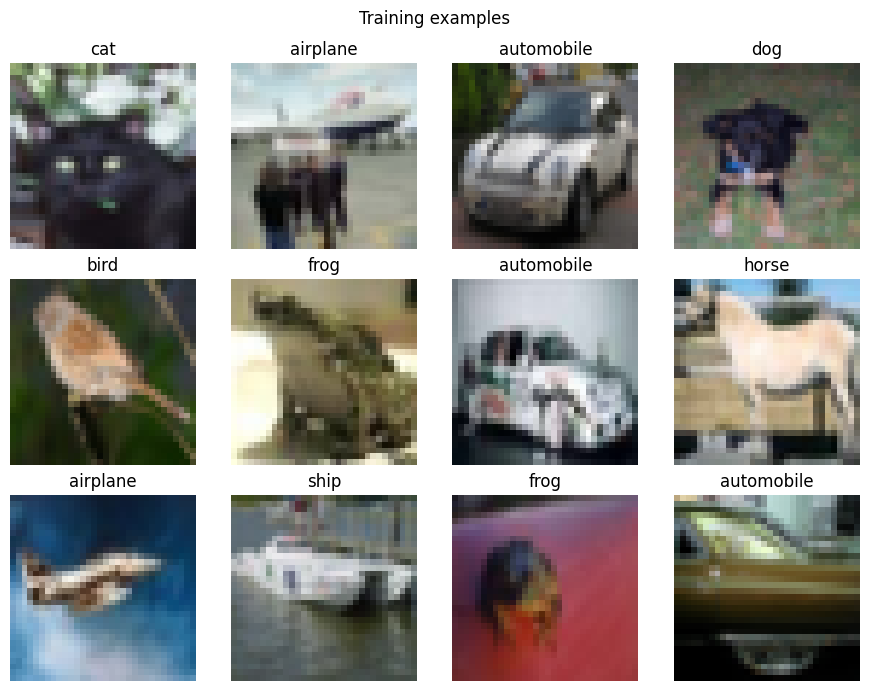

Step 1 complete.


In [ ]:
indices = np.arange(len(labels))
train_idx, held_idx = train_test_split(
    indices, test_size=15000, stratify=labels, random_state=SEED
)
val_idx, remaining_idx = train_test_split(
    held_idx, test_size=10000, stratify=labels[held_idx],
    random_state=SEED
)
cal_idx, policy_idx = train_test_split(
    remaining_idx, test_size=5000, stratify=labels[remaining_idx],
    random_state=SEED
)

splits = {
    "train": train_idx,
    "validation": val_idx,
    "calibration": cal_idx,
    "policy": policy_idx,
}
joined = np.concatenate(list(splits.values()))
assert len(joined) == len(labels)
assert len(np.unique(joined)) == len(labels)

np.savez(PROJECT_DIR / "split_indices.npz", **splits)
for name, idx in splits.items():
    counts = np.bincount(labels[idx], minlength=len(classes))
    print(f"{name}: {len(idx)} images; per class: {counts.tolist()}")

config = {
    "seed": SEED,
    "dataset": "CIFAR-10",
    "classes": classes,
    "split_sizes": {name: len(idx) for name, idx in splits.items()},
    "reserved_official_test_size": 10000,
    "versions": {
        "python": sys.version,
        "torch": torch.__version__,
        "torchvision": torchvision.__version__,
        "numpy": np.__version__,
        "sklearn": sklearn.__version__,
    },
}
(PROJECT_DIR / "config.json").write_text(
    json.dumps(config, indent=2), encoding="utf-8"
)

chosen = np.random.default_rng(SEED).choice(train_idx, 12, replace=False)
fig, axes = plt.subplots(3, 4, figsize=(9, 7))
for ax, idx in zip(axes.flat, chosen):
    image, label = development_data[int(idx)]
    ax.imshow(image)
    ax.set_title(classes[label])
    ax.axis("off")
fig.suptitle("Training examples")
fig.tight_layout()
fig.savefig(PROJECT_DIR / "training_examples.png", dpi=150)
plt.show()
print("Step 1 complete.")


In [ ]:


from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
import pandas as pd
import time

BATCH_SIZE = 128
MEAN = (0.5, 0.5, 0.5)
STD = (0.5, 0.5, 0.5)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_images = CIFAR10(
    root=str(DATA_DIR),
    train=True,
    download=False,
    transform=train_transform,
)

eval_images = CIFAR10(
    root=str(DATA_DIR),
    train=True,
    download=False,
    transform=eval_transform,
)

saved_splits = np.load(PROJECT_DIR / "split_indices.npz")
train_idx = saved_splits["train"]
val_idx = saved_splits["validation"]
cal_idx = saved_splits["calibration"]
policy_idx = saved_splits["policy"]

loader_options = {
    "batch_size": BATCH_SIZE,
    "num_workers": 2,
    "pin_memory": device.type == "cuda",
}

train_loader = DataLoader(
    Subset(train_images, train_idx.tolist()),
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED),
    **loader_options,
)

val_loader = DataLoader(
    Subset(eval_images, val_idx.tolist()),
    shuffle=False,
    **loader_options,
)

images, targets = next(iter(val_loader))

print("Image batch:", images.shape)
print("Label batch:", targets.shape)
print("Training images:", len(train_loader.dataset))
print("Validation images:", len(val_loader.dataset))

Image batch: torch.Size([128, 3, 32, 32])
Label batch: torch.Size([128])
Training images: 35000
Validation images: 5000


In [ ]:


class SmallCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        def block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(
                    in_channels, out_channels,
                    kernel_size=3, padding=1, bias=False,
                ),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),

                nn.Conv2d(
                    out_channels, out_channels,
                    kernel_size=3, padding=1, bias=False,
                ),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),

                nn.MaxPool2d(2),
            )

        self.features = nn.Sequential(
            block(3, 32),
            block(32, 64),
            block(64, 128),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

model = SmallCNN(num_classes=len(classes)).to(device)
model.eval()

with torch.no_grad():
    sample_output = model(images[:4].to(device))

assert sample_output.shape == (4, len(classes))

print("Output shape:", sample_output.shape)
print("Parameters:", sum(p.numel() for p in model.parameters()))

Output shape: torch.Size([4, 10])
Parameters: 814570


Epoch 01/15 | train loss 1.562 | val loss 1.317 | train accuracy 41.9% | val accuracy 52.9% | 17s
Epoch 02/15 | train loss 1.139 | val loss 1.196 | train accuracy 58.9% | val accuracy 59.4% | 16s
Epoch 03/15 | train loss 0.940 | val loss 0.903 | train accuracy 66.6% | val accuracy 68.8% | 16s
Epoch 04/15 | train loss 0.826 | val loss 0.954 | train accuracy 70.9% | val accuracy 68.2% | 17s
Epoch 05/15 | train loss 0.753 | val loss 0.723 | train accuracy 73.8% | val accuracy 75.3% | 17s
Epoch 06/15 | train loss 0.695 | val loss 0.635 | train accuracy 75.6% | val accuracy 78.3% | 15s
Epoch 07/15 | train loss 0.631 | val loss 0.590 | train accuracy 78.1% | val accuracy 80.0% | 15s
Epoch 08/15 | train loss 0.590 | val loss 0.667 | train accuracy 79.5% | val accuracy 77.5% | 16s
Epoch 09/15 | train loss 0.546 | val loss 0.585 | train accuracy 81.2% | val accuracy 80.6% | 16s
Epoch 10/15 | train loss 0.506 | val loss 0.513 | train accuracy 82.3% | val accuracy 82.9% | 16s
Epoch 11/15 | train 

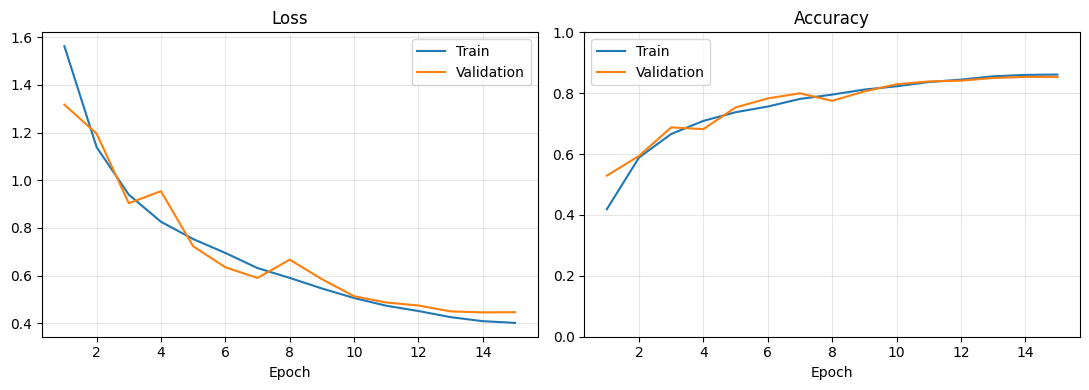

Best validation accuracy: 85.36%
Best epoch: 14
Saved model: /content/drive/MyDrive/Reliable-Vision-Jaber/baseline_seed42_best.pt
Step 2 complete.


In [ ]:


EPOCHS = 15
LEARNING_RATE = 1e-3

torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

train_loader.generator.manual_seed(SEED)
model = SmallCNN(num_classes=len(classes)).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS
)

best_path = PROJECT_DIR / f"baseline_seed{SEED}_best.pt"
history_path = PROJECT_DIR / f"baseline_seed{SEED}_history.csv"

best_val_acc = -1.0
history = []

training_config = {
    "model": "SmallCNN",
    "seed": SEED,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "optimizer": "AdamW",
    "weight_decay": 1e-4,
    "scheduler": "CosineAnnealingLR",
    "normalization_mean": list(MEAN),
    "normalization_std": list(STD),
    "augmentation": [
        "RandomCrop(32, padding=4)",
        "RandomHorizontalFlip()",
    ],
    "checkpoint_selection": "highest validation accuracy",
}

(PROJECT_DIR / f"baseline_seed{SEED}_config.json").write_text(
    json.dumps(training_config, indent=2),
    encoding="utf-8",
)


def run_epoch(loader, training):
    model.train(training)
    total_loss, correct, total = 0.0, 0, 0

    with torch.set_grad_enabled(training):
        for batch_images, batch_labels in loader:
            batch_images = batch_images.to(device, non_blocking=True)
            batch_labels = batch_labels.to(device, non_blocking=True)

            if training:
                optimizer.zero_grad(set_to_none=True)

            logits = model(batch_images)
            loss = criterion(logits, batch_labels)

            if not torch.isfinite(loss).item():
                raise RuntimeError(
                    "Loss is not finite. Stop and check the run."
                )

            if training:
                loss.backward()
                optimizer.step()

            count = batch_labels.size(0)
            total_loss += loss.item() * count
            correct += (
                logits.argmax(1) == batch_labels
            ).sum().item()
            total += count

    return total_loss / total, correct / total


for epoch in range(1, EPOCHS + 1):
    started = time.time()
    current_lr = optimizer.param_groups[0]["lr"]

    train_loss, train_acc = run_epoch(train_loader, training=True)
    val_loss, val_acc = run_epoch(val_loader, training=False)

    scheduler.step()

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_accuracy": train_acc,
        "val_accuracy": val_acc,
        "learning_rate": current_lr,
        "seconds": time.time() - started,
    })

    if val_acc > best_val_acc:
        best_val_acc = val_acc

        torch.save({
            "model_state_dict": {
                key: value.detach().cpu()
                for key, value in model.state_dict().items()
            },
            "epoch": epoch,
            "val_accuracy": val_acc,
            "classes": list(classes),
            "training_config": training_config,
        }, best_path)

    pd.DataFrame(history).to_csv(history_path, index=False)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train loss {train_loss:.3f} | "
        f"val loss {val_loss:.3f} | "
        f"train accuracy {train_acc:.1%} | "
        f"val accuracy {val_acc:.1%} | "
        f"{history[-1]['seconds']:.0f}s",
        flush=True,
    )


checkpoint = torch.load(
    best_path, map_location="cpu", weights_only=True
)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

history_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(
    history_df["epoch"], history_df["train_loss"], label="Train"
)
axes[0].plot(
    history_df["epoch"], history_df["val_loss"], label="Validation"
)
axes[0].set_title("Loss")

axes[1].plot(
    history_df["epoch"], history_df["train_accuracy"], label="Train"
)
axes[1].plot(
    history_df["epoch"], history_df["val_accuracy"], label="Validation"
)
axes[1].set_title("Accuracy")
axes[1].set_ylim(0, 1)

for ax in axes:
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(
    PROJECT_DIR / f"baseline_seed{SEED}_curves.png",
    dpi=150,
)
plt.show()

print(f"Best validation accuracy: {checkpoint['val_accuracy']:.2%}")
print("Best epoch:", checkpoint["epoch"])
print("Saved model:", best_path)
print("Step 2 complete.")

In [ ]:
# Cell 7: Run this after Cell 6 finishes.
# Adjust confidence scores using the calibration images.
# These fitting scores are not final test results.
# Send the printed output when this finishes.

import torch.nn.functional as F

checkpoint = torch.load(
    best_path, map_location="cpu", weights_only=True
)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

calibration_loader = DataLoader(
    Subset(eval_images, cal_idx.tolist()),
    shuffle=False,
    **loader_options,
)

logit_batches, label_batches = [], []

with torch.no_grad():
    for batch_images, batch_labels in calibration_loader:
        logits = model(batch_images.to(device, non_blocking=True))
        logit_batches.append(logits.cpu())
        label_batches.append(batch_labels.cpu())

cal_logits = torch.cat(logit_batches).double()
cal_labels = torch.cat(label_batches).long()

assert len(cal_labels) == len(cal_idx)
assert torch.isfinite(cal_logits).all().item()

log_temperature = nn.Parameter(
    torch.zeros((), dtype=torch.float64)
)

temperature_optimizer = torch.optim.LBFGS(
    [log_temperature],
    lr=0.1,
    max_iter=100,
    line_search_fn="strong_wolfe",
)


def calibration_loss():
    temperature_optimizer.zero_grad()

    current_temperature = log_temperature.clamp(-4, 4).exp()
    loss = F.cross_entropy(
        cal_logits / current_temperature,
        cal_labels,
    )

    loss.backward()
    return loss


nll_before = F.cross_entropy(cal_logits, cal_labels).item()

temperature_optimizer.step(calibration_loss)

temperature = (
    log_temperature.detach().clamp(-4, 4).exp().item()
)

nll_after = F.cross_entropy(
    cal_logits / temperature, cal_labels
).item()

if not np.isfinite(nll_after) or nll_after > nll_before:
    temperature = 1.0
    nll_after = nll_before

predictions_before = cal_logits.argmax(dim=1)
predictions_after = (cal_logits / temperature).argmax(dim=1)

assert torch.equal(predictions_before, predictions_after)

calibrated_path = (
    PROJECT_DIR / f"baseline_seed{SEED}_calibrated.pt"
)

torch.save({
    **checkpoint,
    "temperature": temperature,
    "calibration_size": len(cal_labels),
    "calibration_method": "temperature scaling",
    "log_temperature_bounds": [-4.0, 4.0],
    "calibration_nll_before": nll_before,
    "calibration_nll_after": nll_after,
}, calibrated_path)

np.savez(
    PROJECT_DIR / f"baseline_seed{SEED}_calibration_logits.npz",
    logits=cal_logits.numpy(),
    labels=cal_labels.numpy(),
    indices=cal_idx,
)

print("Calibration images:", len(cal_labels))
print(f"Temperature: {temperature:.4f}")
print(f"Calibration NLL before: {nll_before:.4f}")
print(f"Calibration NLL after:  {nll_after:.4f}")
print("Predicted classes unchanged:", torch.equal(
    predictions_before, predictions_after
))
print("Saved model:", calibrated_path)
print("Step 3 complete.")

Calibration images: 5000
Temperature: 1.1492
Calibration NLL before: 0.4411
Calibration NLL after:  0.4359
Predicted classes unchanged: True
Saved model: /content/drive/MyDrive/Reliable-Vision-Jaber/baseline_seed42_calibrated.pt
Step 3 complete.


In [ ]:


import torch.nn.functional as F

checkpoint = torch.load(
    best_path, map_location="cpu", weights_only=True
)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

calibration_loader = DataLoader(
    Subset(eval_images, cal_idx.tolist()),
    shuffle=False,
    **loader_options,
)

logit_batches, label_batches = [], []

with torch.no_grad():
    for batch_images, batch_labels in calibration_loader:
        logits = model(batch_images.to(device, non_blocking=True))
        logit_batches.append(logits.cpu())
        label_batches.append(batch_labels.cpu())

cal_logits = torch.cat(logit_batches).double()
cal_labels = torch.cat(label_batches).long()

assert len(cal_labels) == len(cal_idx)
assert torch.isfinite(cal_logits).all().item()

log_temperature = nn.Parameter(
    torch.zeros((), dtype=torch.float64)
)

temperature_optimizer = torch.optim.LBFGS(
    [log_temperature],
    lr=0.1,
    max_iter=100,
    line_search_fn="strong_wolfe",
)


def calibration_loss():
    temperature_optimizer.zero_grad()
    current_temperature = log_temperature.clamp(-4, 4).exp()

    loss = F.cross_entropy(
        cal_logits / current_temperature,
        cal_labels,
    )

    loss.backward()
    return loss


nll_before = F.cross_entropy(cal_logits, cal_labels).item()

temperature_optimizer.step(calibration_loss)

temperature = (
    log_temperature.detach().clamp(-4, 4).exp().item()
)

nll_after = F.cross_entropy(
    cal_logits / temperature, cal_labels
).item()

if not np.isfinite(nll_after) or nll_after > nll_before:
    temperature = 1.0
    nll_after = nll_before

predictions_before = cal_logits.argmax(dim=1)
predictions_after = (cal_logits / temperature).argmax(dim=1)

assert torch.equal(predictions_before, predictions_after)

calibrated_path = (
    PROJECT_DIR / f"baseline_seed{SEED}_calibrated.pt"
)

torch.save({
    **checkpoint,
    "temperature": temperature,
    "calibration_size": len(cal_labels),
    "calibration_method": "temperature scaling",
    "log_temperature_bounds": [-4.0, 4.0],
    "calibration_nll_before": nll_before,
    "calibration_nll_after": nll_after,
}, calibrated_path)

np.savez(
    PROJECT_DIR / f"baseline_seed{SEED}_calibration_logits.npz",
    logits=cal_logits.numpy(),
    labels=cal_labels.numpy(),
    indices=cal_idx,
)

print("Calibration images:", len(cal_labels))
print(f"Temperature: {temperature:.4f}")
print(f"Calibration NLL before: {nll_before:.4f}")
print(f"Calibration NLL after:  {nll_after:.4f}")
print("These are calibration fitting scores, not final test scores.")
print("Saved model:", calibrated_path)
print("Step 3 complete.")

Calibration images: 5000
Temperature: 1.1492
Calibration NLL before: 0.4411
Calibration NLL after:  0.4359
These are calibration fitting scores, not final test scores.
Saved model: /content/drive/MyDrive/Reliable-Vision-Jaber/baseline_seed42_calibrated.pt
Step 3 complete.


Policy images: 5000
                    accuracy     NLL     ECE   Brier
Before calibration    0.8426  0.4647  0.0233  0.2246
After calibration     0.8426  0.4578  0.0108  0.2233

Selected threshold: 0.75
Accepted images: 3647/5000
Coverage: 72.94%
Accepted accuracy: 95.04%
Sent for review: 1353/5000


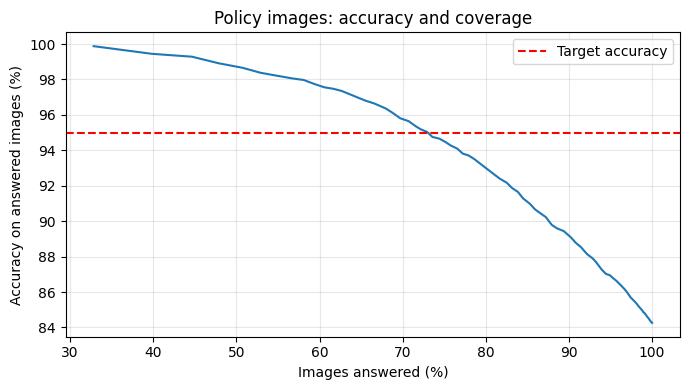

The selected rule still needs final test evaluation.
Step 4 complete.


In [ ]:
# Cell 8: Check confidence on the separate policy images.
# Choose when to answer and when to ask for human review.
# Aim for 95% accuracy on accepted images, keeping at least 500.
# These are development results. The final test is still unused.

checkpoint = torch.load(
    calibrated_path, map_location="cpu", weights_only=True
)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()
temperature = float(checkpoint["temperature"])

policy_loader = DataLoader(
    Subset(eval_images, policy_idx.tolist()),
    shuffle=False,
    **loader_options,
)

logit_batches, label_batches = [], []

with torch.no_grad():
    for batch_images, batch_labels in policy_loader:
        logits = model(batch_images.to(device, non_blocking=True))
        logit_batches.append(logits.cpu())
        label_batches.append(batch_labels.cpu())

policy_logits = torch.cat(logit_batches).double()
policy_labels = torch.cat(label_batches).long()


def confidence_metrics(logits, labels, temperature=1.0):
    scaled_logits = logits / temperature
    probabilities = scaled_logits.softmax(dim=1)

    confidence, predictions = probabilities.max(dim=1)
    correct = predictions.eq(labels).double()

    bin_ids = (confidence * 15).long().clamp(max=14)
    ece = 0.0

    for bin_id in range(15):
        mask = bin_ids == bin_id

        if mask.any():
            gap = abs(
                confidence[mask].mean().item()
                - correct[mask].mean().item()
            )
            ece += mask.double().mean().item() * gap

    one_hot = F.one_hot(
        labels, num_classes=logits.shape[1]
    ).double()

    brier = (
        (probabilities - one_hot).square().sum(dim=1).mean().item()
    )

    return {
        "accuracy": correct.mean().item(),
        "NLL": F.cross_entropy(scaled_logits, labels).item(),
        "ECE": ece,
        "Brier": brier,
    }


comparison = pd.DataFrame({
    "Before calibration": confidence_metrics(
        policy_logits, policy_labels
    ),
    "After calibration": confidence_metrics(
        policy_logits, policy_labels, temperature
    ),
}).T

print("Policy images:", len(policy_labels))
print(comparison.round(4).to_string())

probabilities = (policy_logits / temperature).softmax(dim=1)
confidence, predictions = probabilities.max(dim=1)

policy_confidence = confidence.numpy()
policy_correct = predictions.eq(policy_labels).numpy()

TARGET_ACCURACY = 0.95
MIN_ACCEPTED = 500

rows = []

for threshold in np.linspace(0.0, 1.0, 101):
    accepted = policy_confidence >= threshold
    accepted_count = int(accepted.sum())

    accepted_accuracy = (
        float(policy_correct[accepted].mean())
        if accepted_count else np.nan
    )

    rows.append({
        "threshold": float(threshold),
        "accepted": accepted_count,
        "coverage": accepted_count / len(policy_labels),
        "accepted_accuracy": accepted_accuracy,
        "accepted_error_rate": 1.0 - accepted_accuracy,
    })

threshold_results = pd.DataFrame(rows)

eligible = threshold_results[
    (threshold_results["accepted"] >= MIN_ACCEPTED)
    & (threshold_results["accepted_accuracy"] >= TARGET_ACCURACY)
]

if eligible.empty:
    selected_threshold = 1.000001
    selected_count = 0
    selected_accuracy = None

    print("\nNo threshold met both conditions.")
    print("The current rule sends every image for review.")
else:
    selected = eligible.loc[eligible["coverage"].idxmax()]

    selected_threshold = float(selected["threshold"])
    selected_count = int(selected["accepted"])
    selected_accuracy = float(selected["accepted_accuracy"])

    print(f"\nSelected threshold: {selected_threshold:.2f}")
    print(f"Accepted images: {selected_count}/{len(policy_labels)}")
    print(f"Coverage: {selected['coverage']:.2%}")
    print(f"Accepted accuracy: {selected_accuracy:.2%}")
    print(
        f"Sent for review: "
        f"{len(policy_labels) - selected_count}/{len(policy_labels)}"
    )

policy_config = {
    "method": "calibrated maximum probability",
    "accept_if": "confidence >= threshold",
    "threshold": selected_threshold,
    "temperature": temperature,
    "target_policy_accuracy": TARGET_ACCURACY,
    "minimum_accepted_images": MIN_ACCEPTED,
    "policy_images": len(policy_labels),
    "accepted_policy_images": selected_count,
    "accepted_policy_accuracy": selected_accuracy,
    "checkpoint": calibrated_path.name,
    "checkpoint_epoch": int(checkpoint["epoch"]),
    "final_test_evaluated": False,
}

(PROJECT_DIR / f"baseline_seed{SEED}_review_policy.json").write_text(
    json.dumps(policy_config, indent=2),
    encoding="utf-8",
)

threshold_results.to_csv(
    PROJECT_DIR / f"baseline_seed{SEED}_policy_thresholds.csv",
    index=False,
)

comparison.to_csv(
    PROJECT_DIR / f"baseline_seed{SEED}_policy_calibration_metrics.csv"
)

valid_points = threshold_results[
    threshold_results["accepted"] >= MIN_ACCEPTED
].sort_values("coverage")

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    valid_points["coverage"] * 100,
    valid_points["accepted_accuracy"] * 100,
)
ax.axhline(
    TARGET_ACCURACY * 100,
    color="red",
    linestyle="--",
    label="Target accuracy",
)

ax.set_xlabel("Images answered (%)")
ax.set_ylabel("Accuracy on answered images (%)")
ax.set_title("Policy images: accuracy and coverage")
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(
    PROJECT_DIR / f"baseline_seed{SEED}_policy_accuracy_coverage.png",
    dpi=150,
)
plt.show()

print("The selected rule still needs final test evaluation.")
print("Step 4 complete.")

Fixed review threshold: 0.75
     condition  accuracy    NLL    ECE  coverage  accepted_accuracy  accepted_images  accepted_errors  review_images
         clean    0.8426 0.4578 0.0108    0.7294             0.9504             3647              181           1353
  blur_sigma_1    0.3708 2.2767 0.2708    0.3170             0.5855             1585              657           3415
  blur_sigma_2    0.2350 2.6537 0.3138    0.1756             0.3417              878              578           4122
noise_std_0.05    0.6378 1.1436 0.1110    0.5536             0.8190             2768              501           2232
noise_std_0.10    0.3474 2.3533 0.3383    0.4360             0.4587             2180             1180           2820


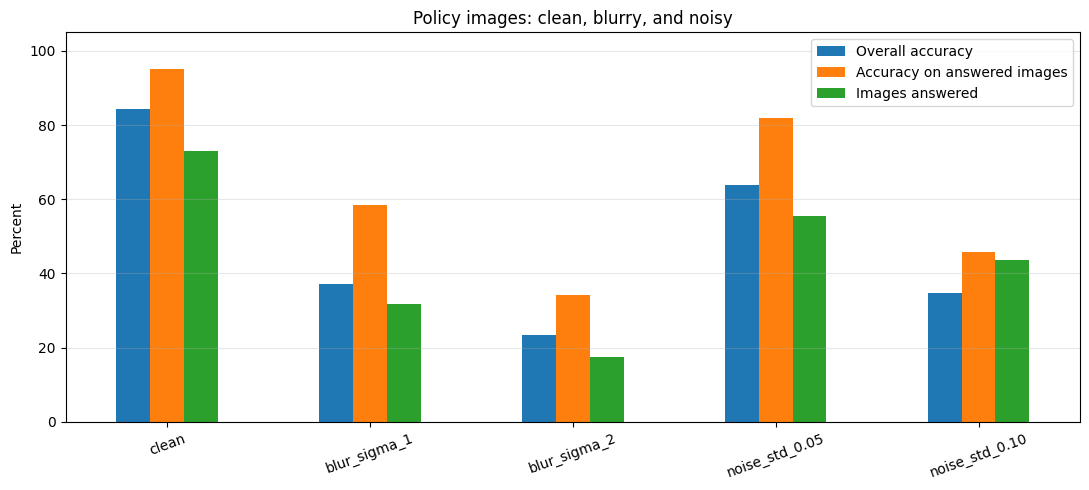

Step 5 complete. Final test images remain unused.


In [ ]:
# Cell 9: Check the same review rule on blurry and noisy images.
# Keep the threshold fixed. Use policy images only.
# Send the table when this finishes.

from torchvision.transforms import functional as TF

review_threshold = float(policy_config["threshold"])

conditions = {
    "clean": {},
    "blur_sigma_1": {"blur_sigma": 1.0},
    "blur_sigma_2": {"blur_sigma": 2.0},
    "noise_std_0.05": {"noise_std": 0.05},
    "noise_std_0.10": {"noise_std": 0.10},
}


def apply_corruption(images, settings, noise_generator):
    if "blur_sigma" in settings:
        images = TF.gaussian_blur(
            images,
            kernel_size=[9, 9],
            sigma=[settings["blur_sigma"]] * 2,
        )

    if "noise_std" in settings:
        channel_std = torch.tensor(
            STD, device=images.device, dtype=images.dtype
        ).view(1, 3, 1, 1)

        channel_mean = torch.tensor(
            MEAN, device=images.device, dtype=images.dtype
        ).view(1, 3, 1, 1)

        pixels = images * channel_std + channel_mean

        noise = torch.randn(
            pixels.shape,
            generator=noise_generator,
            device=pixels.device,
            dtype=pixels.dtype,
        )

        pixels = (
            pixels + noise * settings["noise_std"]
        ).clamp(0, 1)

        images = (pixels - channel_mean) / channel_std

    return images


model.eval()
stress_results = []

for condition_name, settings in conditions.items():
    noise_generator = torch.Generator(
        device=device
    ).manual_seed(SEED + 100)

    logit_batches, label_batches = [], []

    with torch.no_grad():
        for batch_images, batch_labels in policy_loader:
            batch_images = batch_images.to(
                device, non_blocking=True
            )

            changed_images = apply_corruption(
                batch_images,
                settings,
                noise_generator,
            )

            logits = model(changed_images)

            logit_batches.append(logits.cpu())
            label_batches.append(batch_labels.cpu())

    condition_logits = torch.cat(logit_batches).double()
    condition_labels = torch.cat(label_batches).long()

    probabilities = (
        condition_logits / temperature
    ).softmax(dim=1)

    confidence, predictions = probabilities.max(dim=1)
    correct = predictions.eq(condition_labels)
    accepted = confidence >= review_threshold

    accepted_count = int(accepted.sum().item())
    accepted_errors = int(
        (accepted & ~correct).sum().item()
    )

    accepted_accuracy = (
        correct[accepted].double().mean().item()
        if accepted_count else np.nan
    )

    metrics = confidence_metrics(
        condition_logits,
        condition_labels,
        temperature,
    )

    stress_results.append({
        "condition": condition_name,
        "accuracy": metrics["accuracy"],
        "NLL": metrics["NLL"],
        "ECE": metrics["ECE"],
        "coverage": accepted.double().mean().item(),
        "accepted_accuracy": accepted_accuracy,
        "accepted_images": accepted_count,
        "accepted_errors": accepted_errors,
        "review_images": len(condition_labels) - accepted_count,
    })

    np.savez(
        PROJECT_DIR / (
            f"baseline_seed{SEED}_policy_{condition_name}_logits.npz"
        ),
        logits=condition_logits.numpy(),
        labels=condition_labels.numpy(),
        indices=policy_idx,
    )

stress_df = pd.DataFrame(stress_results)

print(f"Fixed review threshold: {review_threshold:.2f}")
print(stress_df.round(4).to_string(index=False))

stress_df.to_csv(
    PROJECT_DIR / f"baseline_seed{SEED}_policy_stress_results.csv",
    index=False,
)

stress_config = {
    "split": "policy",
    "conditions": conditions,
    "noise_seed": SEED + 100,
    "review_threshold": review_threshold,
    "temperature": temperature,
    "checkpoint": calibrated_path.name,
    "final_test_evaluated": False,
}

(PROJECT_DIR / f"baseline_seed{SEED}_stress_config.json").write_text(
    json.dumps(stress_config, indent=2),
    encoding="utf-8",
)

plot_data = stress_df.set_index("condition")[[
    "accuracy",
    "accepted_accuracy",
    "coverage",
]] * 100

plot_data.columns = [
    "Overall accuracy",
    "Accuracy on answered images",
    "Images answered",
]

ax = plot_data.plot(
    kind="bar",
    figsize=(11, 5),
    rot=20,
)

ax.set_ylabel("Percent")
ax.set_xlabel("")
ax.set_ylim(0, 105)
ax.set_title("Policy images: clean, blurry, and noisy")
ax.grid(axis="y", alpha=0.3)

fig = ax.get_figure()
fig.tight_layout()
fig.savefig(
    PROJECT_DIR / f"baseline_seed{SEED}_policy_stress_plot.png",
    dpi=150,
)
plt.show()

print("Step 5 complete. Final test images remain unused.")

In [ ]:
# Cell 10: Confidence still accepts many wrong blurry and noisy images.
# Test whether agreement across small image changes helps.
# Choose the new threshold on clean policy images, then check the corruptions.
# Keep the original confidence rule for comparison.

from sklearn.metrics import roc_auc_score

model.eval()

CONSISTENCY_VIEWS = {
    "horizontal_flip": True,
    "blur_sigma": 0.5,
    "noise_std": 0.02,
}


@torch.no_grad()
def predict_with_consistency(images, noise_generator):
    logits = model(images)
    probabilities = (logits.double() / temperature).softmax(dim=1)
    confidence, predictions = probabilities.max(dim=1)

    views = [
        images.flip(-1),
        apply_corruption(
            images,
            {"blur_sigma": CONSISTENCY_VIEWS["blur_sigma"]},
            noise_generator,
        ),
        apply_corruption(
            images,
            {"noise_std": CONSISTENCY_VIEWS["noise_std"]},
            noise_generator,
        ),
    ]

    matches = [
        model(view).argmax(dim=1).eq(predictions)
        for view in views
    ]

    agreement = torch.stack(matches).double().mean(dim=0)
    score = confidence * agreement

    return confidence, predictions, agreement, score


consistency_data = {}

for condition_name, settings in conditions.items():
    corruption_generator = torch.Generator(
        device=device
    ).manual_seed(SEED + 100)

    view_generator = torch.Generator(
        device=device
    ).manual_seed(SEED + 200)

    collected = {
        "confidence": [],
        "predictions": [],
        "agreement": [],
        "score": [],
        "labels": [],
    }

    for batch_images, batch_labels in policy_loader:
        batch_images = batch_images.to(device, non_blocking=True)

        changed_images = apply_corruption(
            batch_images,
            settings,
            corruption_generator,
        )

        confidence, predictions, agreement, score = (
            predict_with_consistency(changed_images, view_generator)
        )

        collected["confidence"].append(confidence.cpu().numpy())
        collected["predictions"].append(predictions.cpu().numpy())
        collected["agreement"].append(agreement.cpu().numpy())
        collected["score"].append(score.cpu().numpy())
        collected["labels"].append(batch_labels.numpy())

    data = {
        name: np.concatenate(batches)
        for name, batches in collected.items()
    }

    data["correct"] = data["predictions"] == data["labels"]
    consistency_data[condition_name] = data

    np.savez(
        PROJECT_DIR / (
            f"baseline_seed{SEED}_policy_{condition_name}_consistency.npz"
        ),
        **data,
        indices=policy_idx,
    )

    print("Processed:", condition_name, flush=True)


clean_data = consistency_data["clean"]
threshold_rows = []

for threshold in np.linspace(0.0, 1.0, 101):
    accepted = clean_data["score"] >= threshold
    count = int(accepted.sum())

    accuracy = (
        float(clean_data["correct"][accepted].mean())
        if count else np.nan
    )

    threshold_rows.append({
        "threshold": float(threshold),
        "accepted": count,
        "coverage": count / len(accepted),
        "accepted_accuracy": accuracy,
    })

consistency_thresholds = pd.DataFrame(threshold_rows)

eligible = consistency_thresholds[
    (consistency_thresholds["accepted"] >= MIN_ACCEPTED)
    & (consistency_thresholds["accepted_accuracy"] >= TARGET_ACCURACY)
]

if eligible.empty:
    consistency_threshold = 1.000001
    print("\nNo consistency threshold met both conditions.")
else:
    selected = eligible.loc[eligible["coverage"].idxmax()]
    consistency_threshold = float(selected["threshold"])

    print(f"\nConsistency threshold: {consistency_threshold:.2f}")
    print(f"Clean policy coverage: {selected['coverage']:.2%}")
    print(
        f"Clean accepted accuracy: "
        f"{selected['accepted_accuracy']:.2%}"
    )


comparison_rows = []

for condition_name, data in consistency_data.items():
    correct = data["correct"]
    errors = ~correct

    methods = {
        "confidence": (
            data["confidence"],
            review_threshold,
        ),
        "confidence + agreement": (
            data["score"],
            consistency_threshold,
        ),
    }

    for method_name, (scores, threshold) in methods.items():
        accepted = scores >= threshold
        count = int(accepted.sum())

        accepted_accuracy = (
            float(correct[accepted].mean())
            if count else np.nan
        )

        error_auroc = (
            roc_auc_score(errors.astype(int), 1.0 - scores)
            if np.unique(errors).size == 2 else np.nan
        )

        comparison_rows.append({
            "condition": condition_name,
            "method": method_name,
            "accuracy": float(correct.mean()),
            "coverage": float(accepted.mean()),
            "accepted_accuracy": accepted_accuracy,
            "accepted_images": count,
            "accepted_errors": int((accepted & errors).sum()),
            "error_AUROC": float(error_auroc),
            "mean_agreement": float(data["agreement"].mean()),
        })


consistency_comparison = pd.DataFrame(comparison_rows)

print("\nPolicy comparison:")
print(consistency_comparison.round(4).to_string(index=False))

consistency_comparison.to_csv(
    PROJECT_DIR / f"baseline_seed{SEED}_policy_method_comparison.csv",
    index=False,
)

consistency_thresholds.to_csv(
    PROJECT_DIR / f"baseline_seed{SEED}_consistency_thresholds.csv",
    index=False,
)

consistency_config = {
    "method": "calibrated confidence multiplied by view agreement",
    "threshold": consistency_threshold,
    "threshold_selection_split": "clean policy",
    "target_policy_accuracy": TARGET_ACCURACY,
    "minimum_accepted_images": MIN_ACCEPTED,
    "views": CONSISTENCY_VIEWS,
    "blur_kernel_size": 9,
    "view_noise_seed": SEED + 200,
    "corruption_noise_seed": SEED + 100,
    "temperature": temperature,
    "checkpoint": calibrated_path.name,
    "checkpoint_epoch": int(checkpoint["epoch"]),
    "final_test_evaluated": False,
}

(PROJECT_DIR / f"baseline_seed{SEED}_consistency_policy.json").write_text(
    json.dumps(consistency_config, indent=2),
    encoding="utf-8",
)

print("\nStep 6 complete. Final test images remain unused.")

Processed: clean
Processed: blur_sigma_1
Processed: blur_sigma_2
Processed: noise_std_0.05
Processed: noise_std_0.10

Consistency threshold: 0.70
Clean policy coverage: 71.82%
Clean accepted accuracy: 95.15%

Policy comparison:
     condition                 method  accuracy  coverage  accepted_accuracy  accepted_images  accepted_errors  error_AUROC  mean_agreement
         clean             confidence    0.8426    0.7294             0.9504             3647              181       0.8834          0.9032
         clean confidence + agreement    0.8426    0.7182             0.9515             3591              174       0.8807          0.9032
  blur_sigma_1             confidence    0.3708    0.3170             0.5855             1585              657       0.6855          0.8219
  blur_sigma_1 confidence + agreement    0.3708    0.3584             0.5485             1792              809       0.6763          0.8219
  blur_sigma_2             confidence    0.2350    0.1756             0.

In [ ]:

import hashlib

confidence_rule = json.loads(
    (PROJECT_DIR / f"baseline_seed{SEED}_review_policy.json").read_text()
)

agreement_rule = json.loads(
    (PROJECT_DIR / f"baseline_seed{SEED}_consistency_policy.json").read_text()
)

checkpoint_path = PROJECT_DIR / confidence_rule["checkpoint"]
checkpoint_hash = hashlib.sha256(checkpoint_path.read_bytes()).hexdigest()

frozen_config = {
    "checkpoint_sha256": checkpoint_hash,
    "confidence_rule": confidence_rule,
    "agreement_rule": agreement_rule,
    "conditions": conditions,
    "test_corruption_seed": SEED + 1000,
    "test_view_seed": SEED + 2000,
}

manifest_path = PROJECT_DIR / f"baseline_seed{SEED}_frozen_test_config.json"

if manifest_path.exists():
    previous_config = json.loads(manifest_path.read_text())
    if previous_config != frozen_config:
        raise RuntimeError(
            "The rules differ from the frozen test configuration."
        )
else:
    manifest_path.write_text(
        json.dumps(frozen_config, indent=2),
        encoding="utf-8",
    )

checkpoint = torch.load(
    checkpoint_path, map_location="cpu", weights_only=True
)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

temperature = float(checkpoint["temperature"])
review_threshold = float(confidence_rule["threshold"])
consistency_threshold = float(agreement_rule["threshold"])
test_views = agreement_rule["views"]

MEAN = tuple(checkpoint["training_config"]["normalization_mean"])
STD = tuple(checkpoint["training_config"]["normalization_std"])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

test_images = CIFAR10(
    root=str(DATA_DIR),
    train=False,
    download=False,
    transform=test_transform,
)

test_loader = DataLoader(
    test_images,
    shuffle=False,
    **loader_options,
)

assert len(test_images) == 10000
assert test_images.classes == checkpoint["classes"]

test_data = {}

for condition_name, settings in conditions.items():
    cache_path = PROJECT_DIR / (
        f"baseline_seed{SEED}_test_{condition_name}_predictions.npz"
    )

    if cache_path.exists():
        with np.load(cache_path) as saved:
            test_data[condition_name] = {
                name: saved[name].copy()
                for name in saved.files
            }

        print("Loaded saved predictions:", condition_name)
        continue

    corruption_generator = torch.Generator(
        device=device
    ).manual_seed(frozen_config["test_corruption_seed"])

    view_generator = torch.Generator(
        device=device
    ).manual_seed(frozen_config["test_view_seed"])

    collected = {
        "logits": [],
        "labels": [],
        "confidence": [],
        "predictions": [],
        "agreement": [],
        "score": [],
    }

    with torch.no_grad():
        for batch_images, batch_labels in test_loader:
            batch_images = batch_images.to(device, non_blocking=True)

            changed_images = apply_corruption(
                batch_images, settings, corruption_generator
            )

            logits = model(changed_images)
            probabilities = (
                logits.double() / temperature
            ).softmax(dim=1)

            confidence, predictions = probabilities.max(dim=1)

            views = [
                changed_images.flip(-1),
                apply_corruption(
                    changed_images,
                    {"blur_sigma": test_views["blur_sigma"]},
                    view_generator,
                ),
                apply_corruption(
                    changed_images,
                    {"noise_std": test_views["noise_std"]},
                    view_generator,
                ),
            ]

            matches = [
                model(view).argmax(dim=1).eq(predictions)
                for view in views
            ]

            agreement = torch.stack(matches).double().mean(dim=0)
            score = confidence * agreement

            collected["logits"].append(logits.cpu().numpy())
            collected["labels"].append(batch_labels.numpy())
            collected["confidence"].append(confidence.cpu().numpy())
            collected["predictions"].append(predictions.cpu().numpy())
            collected["agreement"].append(agreement.cpu().numpy())
            collected["score"].append(score.cpu().numpy())

    data = {
        name: np.concatenate(batches)
        for name, batches in collected.items()
    }

    data["correct"] = data["predictions"] == data["labels"]
    assert len(data["labels"]) == 10000

    np.savez_compressed(cache_path, **data)
    test_data[condition_name] = data

    print("Finished test condition:", condition_name, flush=True)

print("Test predictions are ready.")

Finished test condition: clean
Finished test condition: blur_sigma_1
Finished test condition: blur_sigma_2
Finished test condition: noise_std_0.05
Finished test condition: noise_std_0.10
Test predictions are ready.


In [ ]:


def wilson_interval(correct_count, total_count):
    if total_count == 0:
        return np.nan, np.nan

    z = 1.959963984540054
    proportion = correct_count / total_count
    denominator = 1 + z**2 / total_count

    center = (
        proportion + z**2 / (2 * total_count)
    ) / denominator

    margin = (
        z * np.sqrt(
            proportion * (1 - proportion) / total_count
            + z**2 / (4 * total_count**2)
        ) / denominator
    )

    return max(0.0, center - margin), min(1.0, center + margin)


final_rows = []
calibration_rows = []

for condition_name, data in test_data.items():
    correct = data["correct"]
    errors = ~correct

    methods = {
        "answer every image": np.ones(len(correct), dtype=bool),
        "confidence": data["confidence"] >= review_threshold,
        "confidence + agreement": (
            data["score"] >= consistency_threshold
        ),
    }

    for method_name, accepted in methods.items():
        count = int(accepted.sum())
        correct_count = int((accepted & correct).sum())
        error_count = count - correct_count

        low, high = wilson_interval(correct_count, count)

        if method_name == "answer every image":
            error_auroc = np.nan
        else:
            scores = (
                data["confidence"]
                if method_name == "confidence"
                else data["score"]
            )

            error_auroc = (
                roc_auc_score(errors.astype(int), 1.0 - scores)
                if np.unique(errors).size == 2 else np.nan
            )

        final_rows.append({
            "condition": condition_name,
            "method": method_name,
            "coverage": count / len(correct),
            "accepted_accuracy": (
                correct_count / count if count else np.nan
            ),
            "accuracy_95CI_low": low,
            "accuracy_95CI_high": high,
            "accepted_images": count,
            "accepted_errors": error_count,
            "review_images": len(correct) - count,
            "error_AUROC": float(error_auroc),
        })

    logits = torch.from_numpy(data["logits"]).double()
    labels = torch.from_numpy(data["labels"]).long()

    for name, fitted_temperature in [
        ("before calibration", 1.0),
        ("after calibration", temperature),
    ]:
        metrics = confidence_metrics(
            logits, labels, fitted_temperature
        )

        calibration_rows.append({
            "condition": condition_name,
            "calibration": name,
            **metrics,
        })


final_results = pd.DataFrame(final_rows)
final_calibration = pd.DataFrame(calibration_rows)

print("FINAL TEST: FROZEN REVIEW RULES")
print(final_results.round(4).to_string(index=False))

print("\nFINAL TEST: CONFIDENCE CALIBRATION")
print(final_calibration.round(4).to_string(index=False))

final_results.to_csv(
    PROJECT_DIR / f"baseline_seed{SEED}_final_test_results.csv",
    index=False,
)

final_calibration.to_csv(
    PROJECT_DIR / f"baseline_seed{SEED}_final_test_calibration.csv",
    index=False,
)



FINAL TEST: FROZEN REVIEW RULES
     condition                 method  coverage  accepted_accuracy  accuracy_95CI_low  accuracy_95CI_high  accepted_images  accepted_errors  review_images  error_AUROC
         clean     answer every image    1.0000             0.8434             0.8361              0.8504            10000             1566              0          NaN
         clean             confidence    0.7365             0.9457             0.9403              0.9506             7365              400           2635       0.8784
         clean confidence + agreement    0.7198             0.9498             0.9446              0.9547             7198              361           2802       0.8786
  blur_sigma_1     answer every image    1.0000             0.3784             0.3689              0.3880            10000             6216              0          NaN
  blur_sigma_1             confidence    0.3172             0.5776             0.5603              0.5946             3172      